# Time Series LAX Passenger Traffic Analysis

The dataset used in this analysis is Los Angeles International Airport Passenger Traffic by Terminal, which contains monthly and yearly totals of passenger traffic segmented by terminal. This dataset was obtained directly from the official City of Los Angeles government website, ensuring its reliability and accuracy.

This notebook analyzes traffic patterns at LAX to predict overall traffic levels. We are going to leverage individual terminal traffic data to understand how each terminal contributes to total congestion and identify patterns over time. The analysis helps identify current bottlenecks, forecast future traffic volumes, and support infrastructure planning decisions that can improve traffic flow and reduce congestion around the airport.

In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose


In [ ]:
df= pd.read_csv('/content/LAX_Passenger_Traffic_By_Terminal_2020.csv')

In [ ]:
# Initial Inspection of Data
df.head(5)

,DataExtractDate,ReportPeriod,Terminal,Arrival_Departure,Domestic_International,Passenger_Count
0,2021 May 10 06:01:09 AM,2021 Apr 01 12:00:00 AM,T1,Departure,Domestic,"160,413"
1,2021 May 03 03:08:02 PM,2021 Mar 01 12:00:00 AM,T5,Departure,Domestic,"223,866"
2,2021 May 27 03:16:34 PM,2021 Apr 01 12:00:00 AM,T5,Departure,Domestic,"266,035"
3,2021 Jul 10 06:01:27 AM,2021 Jun 01 12:00:00 AM,T6,Arrival,International,"6,195"
4,2021 May 10 06:01:09 AM,2021 Apr 01 12:00:00 AM,T8,Arrival,Domestic,"54,925"


In [ ]:
# Sampling through to ensure consistency
df.sample(10)

,DataExtractDate,ReportPeriod,Terminal,Arrival_Departure,Domestic_International,Passenger_Count
730,2022 Oct 01 12:00:21 AM,2022 Aug 01 12:00:00 AM,TBIT West Gates,Departure,International,"173,701"
6220,2018 Apr 18 03:12:41 PM,2015 Jul 01 12:00:00 AM,TBIT,Arrival,International,"665,148"
738,2023 Jan 10 06:01:14 AM,2022 Dec 01 12:00:00 AM,T1,Arrival,Domestic,"244,879"
2106,2018 Apr 18 03:12:41 PM,2012 Apr 01 12:00:00 AM,T8,Departure,International,"7,282"
4663,2018 Dec 26 06:52:40 AM,2018 Nov 01 12:00:00 AM,TBIT,Departure,Domestic,"20,608"
2185,2020 Apr 29 07:14:24 AM,2020 Mar 01 12:00:00 AM,T6,Arrival,International,"24,609"
5420,2018 Apr 18 03:12:41 PM,2009 Jul 01 12:00:00 AM,T4,Departure,Domestic,"414,432"
6662,2018 Apr 18 03:12:41 PM,2009 Jul 01 12:00:00 AM,T4,Arrival,International,"32,439"
4971,2018 Apr 18 03:12:41 PM,2010 Feb 01 12:00:00 AM,T7,Arrival,International,"13,656"
5897,2018 Apr 18 03:12:41 PM,2017 Nov 01 12:00:00 AM,Miscellaneous Terminal,Arrival,International,"4,794"


In [ ]:
# Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7883 entries, 0 to 7882
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   DataExtractDate         7883 non-null   object
 1   ReportPeriod            7883 non-null   object
 2   Terminal                7883 non-null   object
 3   Arrival_Departure       7883 non-null   object
 4   Domestic_International  7883 non-null   object
 5   Passenger_Count         7883 non-null   object
dtypes: object(6)
memory usage: 369.6+ KB


In [ ]:
# Remove missing values
df.dropna(inplace=True)

In [ ]:
# Basic statistic overview
df.describe()

,DataExtractDate,ReportPeriod,Terminal,Arrival_Departure,Domestic_International,Passenger_Count
count,7883,7883,7883,7883,7883,7883
unique,150,214,12,2,2,7534
top,2018 Apr 18 03:12:41 PM,2022 Jul 01 12:00:00 AM,T7,Departure,Domestic,0
freq,5394,42,854,4031,4288,11


In [ ]:
# Checking Random samples of data
df.sample(5)

,DataExtractDate,ReportPeriod,Terminal,Arrival_Departure,Domestic_International,Passenger_Count
5142,2018 Apr 18 03:12:41 PM,2008 Oct 01 12:00:00 AM,T5,Departure,Domestic,"161,437"
4809,2018 Apr 18 03:12:41 PM,2006 May 01 12:00:00 AM,T4,Departure,International,"49,805"
5924,2018 Aug 21 11:02:45 AM,2018 Jul 01 12:00:00 AM,T6,Arrival,International,"104,500"
3374,2018 Apr 18 03:12:41 PM,2012 Oct 01 12:00:00 AM,T4,Arrival,International,"19,912"
5488,2018 Apr 18 03:12:41 PM,2007 Aug 01 12:00:00 AM,T8,Arrival,Domestic,"107,231"


In [ ]:
# ReportPeriod is the most critical variable of the Dataset
# Convert to datetime for proper use within our Time Series Analysis
df['ReportPeriod'] = pd.to_datetime(df['ReportPeriod'])

/tmp/ipykernel_24919/3274132728.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ReportPeriod'] = pd.to_datetime(df['ReportPeriod'])


In [ ]:
# Setting primary index
df.set_index('ReportPeriod', inplace=True)

### PreProcessing:

This section focuses on data preprocessing. Although the dataset originates from the City of Los Angeles and is largely pre-cleaned, additional steps are necessary to ensure it is fully prepared for further analysis and modeling. The primary focus be the Passenger_Count, but we should also check if our Terminals are correct.

In [ ]:
# Dropping missing values/NaNs
df = df.dropna()

In [ ]:
# Double-checking & Processing Individual Columns
# LAX contains 9 offical terminals
df['Terminal'].value_counts()

,count
Terminal,
T7,854
T6,853
T2,851
T4,845
T5,815
T8,802
TBIT,789
Miscellaneous Terminal,699
T3,679


We have around a total of 9 Terminal, yet our column contains around 11 Terminal. Since TBIT and TBIT West Gates are the same terminals we will combine those. Imperial Terminal is not a offical terminal of LAX, instead being a private charter facility and will thus be dropped. Miscellaneous Terminal will be kept around for now to for overall Traffic. Will be considered inrevelant for Terminal analysis.

In [ ]:
# Aggregating TBIT West Gates Together with TBIT
df['Terminal'] = df['Terminal'].replace('TBIT West Gates', 'TBIT')

In [ ]:
# Dropping Imperial Terminal Column
df.drop(df[df["Terminal"] == "Imperial Terminal"].index, inplace=True)

In [ ]:
# Double-checking if drop was sucessful
df[df["Terminal"] == "Imperial Terminal"]

,DataExtractDate,Terminal,Arrival_Departure,Domestic_International,Passenger_Count
ReportPeriod,,,,,


In [ ]:
# Final Check
df['Terminal'].value_counts()

,count
Terminal,
TBIT,759
T7,658
T6,657
T2,655
T4,649
T8,630
T5,619
Miscellaneous Terminal,577
T3,494


In [ ]:
# Checking individual column for any errors
df['Arrival_Departure'].value_counts()

,count
Arrival_Departure,
Departure,3107
Arrival,2952


In [ ]:
# Checking individual columns for oddities
df['Domestic_International'].value_counts()

,count
Domestic_International,
Domestic,3287
International,2772


In [ ]:
# Passenger_Count is listed dtype as string due to commas, let's replace
df["Passenger_Count"] = df["Passenger_Count"].str.replace(",", "")

In [ ]:
# Converting to int type
df['Passenger_Count'] = df['Passenger_Count'].astype(int)

In [ ]:
# Final Check
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6059 entries, 2021-04-01 to 2011-02-01
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   DataExtractDate         6059 non-null   object
 1   Terminal                6059 non-null   object
 2   Arrival_Departure       6059 non-null   object
 3   Domestic_International  6059 non-null   object
 4   Passenger_Count         6059 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 284.0+ KB


### Graph Visualization

We will conduct basic graphical visualizations to identify underlying patterns in the data, including trends, seasonality, and potential anomalies, as well as to assess data consistency and overall distribution.

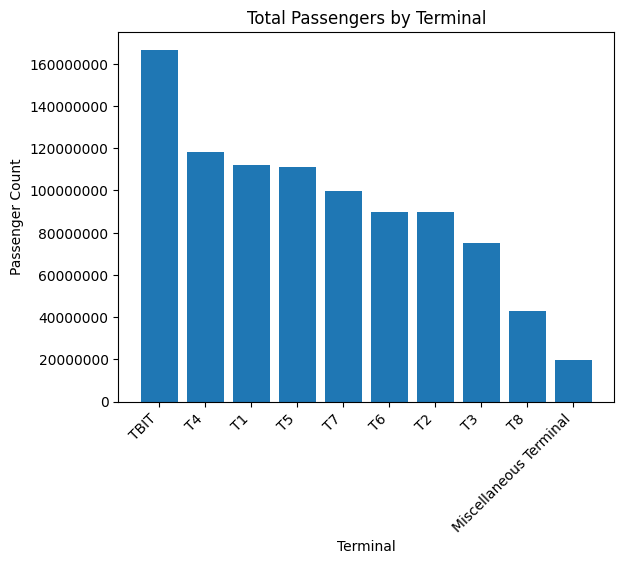

In [ ]:
# Bar Graph of Total Passengers per Terminal
df_sort = df.groupby('Terminal')['Passenger_Count'].sum().sort_values(ascending=False)

plt.ticklabel_format(style='plain', axis='y')
plt.bar(df_sort.index, df_sort.values)
plt.xlabel('Terminal')
plt.ylabel('Passenger Count')
plt.title('Total Passengers by Terminal')
plt.xticks(rotation=45, ha='right')
plt.show()

Tom Brady International Airport containg the largest volume of Traffic around 16m total passengers from ~2008-2024. It's followed a drop of around ~4m passengers for Terminal 4, and then slightly decreases for Terminal 1, 5, and etc.

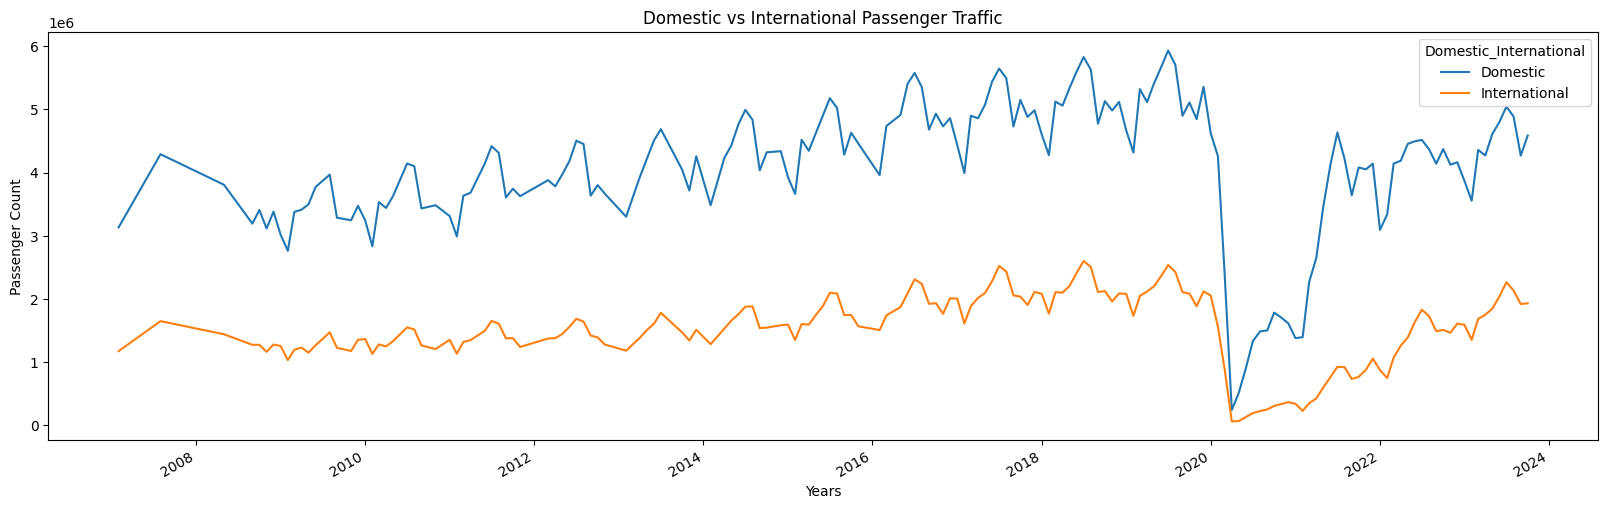

In [ ]:
# Total Passenger Traffic over time Domestic vs International
dom_int = (df.groupby(["ReportPeriod", "Domestic_International"])["Passenger_Count"].sum().unstack(fill_value=0).sort_index())

dom_int.plot(figsize=(20, 6))
plt.title("Domestic vs International Passenger Traffic")
plt.xlabel("Years")
plt.ylabel("Passenger Count")
plt.show()

Domestic Flights make up the majority of Passenger volume for LAX, with increasing amount of Traffic year-by-year until 2020 where Traffic suddenly crashed. After 2021, Traffic dramatically rebounded for domestic but international never quite recovered as well as Domestic. Additionally, we can see no extremities within the line grpah indicting no data error, beside for 2020 which is explained by COVID-19. This graph ensure the robustness and accuracy of our dataset

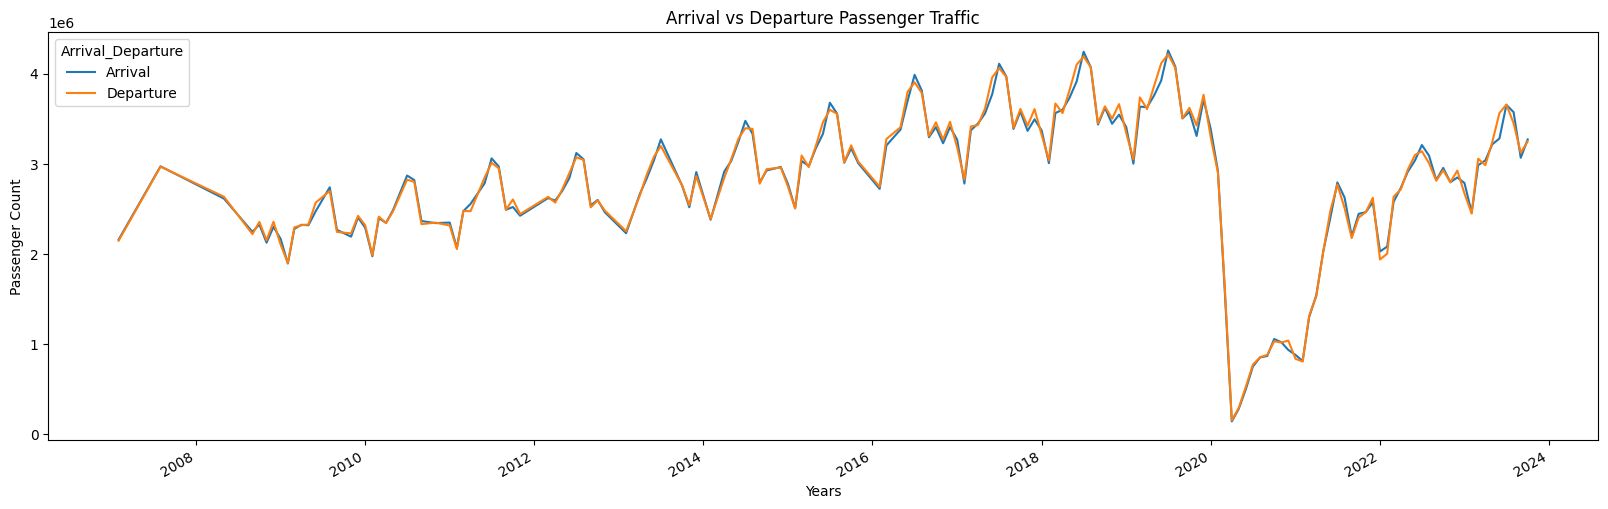

In [ ]:
# Total Passenger Traffic over time Arrival vs Departure
arr_dep = (df.groupby(["ReportPeriod", "Arrival_Departure"])["Passenger_Count"].sum().unstack(fill_value=0).sort_index())

arr_dep.plot(figsize=(20, 6))
plt.title("Arrival vs Departure Passenger Traffic")
plt.xlabel("Years")
plt.ylabel("Passenger Count")
plt.show()

Time-series plot over the years shows that arrival and departure distributions are evenly distributed, with both following the same line trajectory.

Text(0, 0.5, 'Passenger Count')

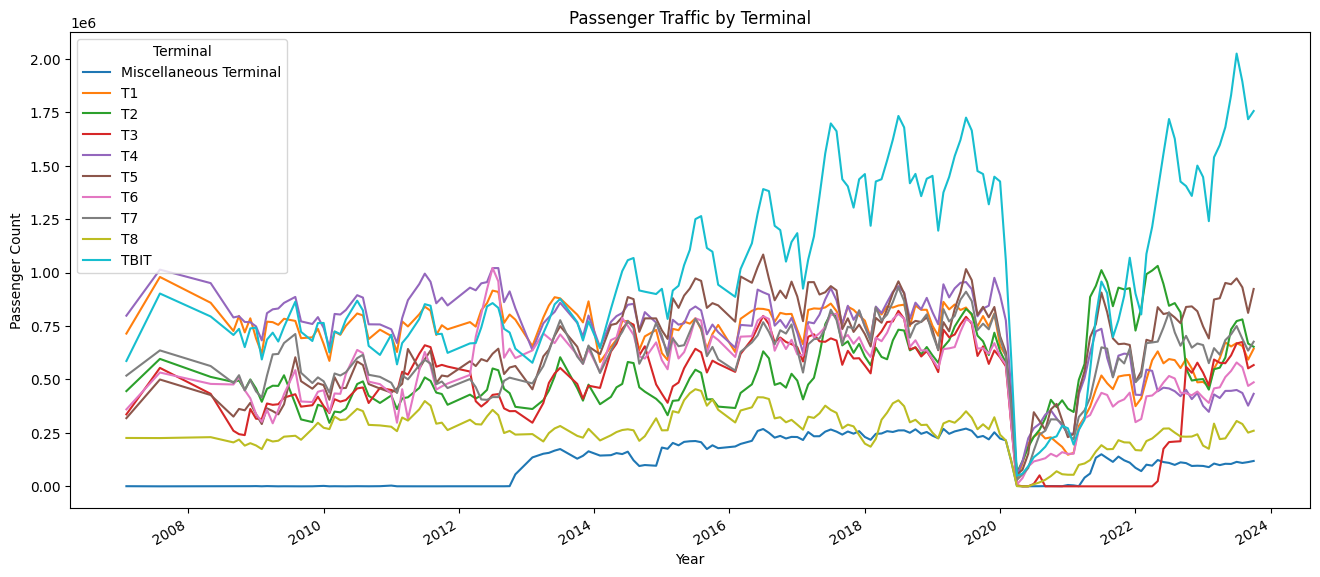

In [ ]:
# Line Graph for Pasasenger Traffic by Terminal Over Time
terminal_total = (df.groupby(["ReportPeriod", "Terminal"])["Passenger_Count"].sum().unstack(fill_value=0).sort_index())

terminal_total.plot(figsize=(16, 7))
plt.title("Passenger Traffic by Terminal")
plt.xlabel("Year")
plt.ylabel("Passenger Count")

Terminal traffic levels were relatively similar across all terminals until approximately 2014. From 2014 to 2020, TBIT began to diverge from the others, showing a noticeable increase in passenger traffic prior to the sharp decline observed in 2020. After 2017 TBIT continue to diverge from the other Terminals Traffic volume. Despite the drop in 2020, TBIT continues to breakaway beginning in 2023.

# Statistical Modeling
- ETS Decomposition
- SMA & EWMA

We apply statistical time series modeling techniques to LAX passenger traffic to better understand its underlying structure and support reliable forecasting. Methods such as ETS (Error–Trend–Seasonality) decomposition allow us to break the data into key components—trend, seasonal patterns, and irregular fluctuations. It provides insight into how passenger volumes change over time. Smoothing techniques like Simple Moving Average (SMA) and Exponentially Weighted Moving Average (EWMA) help reduce short-term noise and emphasize longer-term patterns, making the data easier to interpret. Together, these approaches enhance our ability to detect meaningful trends, account for seasonality, and produce more accurate forecasts for planning and operational decision-making.

In [ ]:
# Grouping the total Passenger_Volume per Yearly/Monthly timedate
monthly_total = (df.groupby('ReportPeriod')['Passenger_Count']).sum().sort_index()

In [ ]:
# Checking passenger_count accuracy & sum
print(monthly_total.index)

DatetimeIndex(['2007-02-01', '2007-08-01', '2008-05-01', '2008-09-01',
               '2008-10-01', '2008-11-01', '2008-12-01', '2009-01-01',
               '2009-02-01', '2009-03-01',
               ...
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01'],
              dtype='datetime64[ns]', name='ReportPeriod', length=165, freq=None)


I noticed we are missing some Month within our Dataset, let check to see if this will make a big impact on the overall analysis

In [ ]:
# Finding the range of missing months
full_range = pd.date_range(
    start=monthly_total.index.min(),
    end=monthly_total.index.max(),
        freq='MS'
)

missing_dates = full_range.difference(monthly_total.index)
print(f"# of Missing dates: {len(missing_dates)}")
print(f"Missing dates: {(missing_dates)}")

# of Missing dates: 36
Missing dates: DatetimeIndex(['2007-03-01', '2007-04-01', '2007-05-01', '2007-06-01',
               '2007-07-01', '2007-09-01', '2007-10-01', '2007-11-01',
               '2007-12-01', '2008-01-01', '2008-02-01', '2008-03-01',
               '2008-04-01', '2008-06-01', '2008-07-01', '2008-08-01',
               '2009-07-01', '2009-10-01', '2010-06-01', '2010-10-01',
               '2010-12-01', '2011-05-01', '2011-12-01', '2012-01-01',
               '2012-02-01', '2012-12-01', '2013-01-01', '2013-03-01',
               '2013-08-01', '2013-09-01', '2014-01-01', '2014-03-01',
               '2014-11-01', '2015-12-01', '2016-01-01', '2016-04-01'],
              dtype='datetime64[ns]', freq=None)


We are missing some early year's months with 2007, 2008, 2011, and 2012 suffering from the loss of monthly counts of traffic. However, this shouldn't make a big impact on our Time-series analysis as: The gaps are isolated to the early period and don't affect recent trends. We have complete year-over-year data from 2013 onwards. Some time-series models like ARIMA are robust to early data gaps when the majority of the series is complete. Our primary interest is understanding current patterns and forecasting future traffic, which relies more on recent complete data

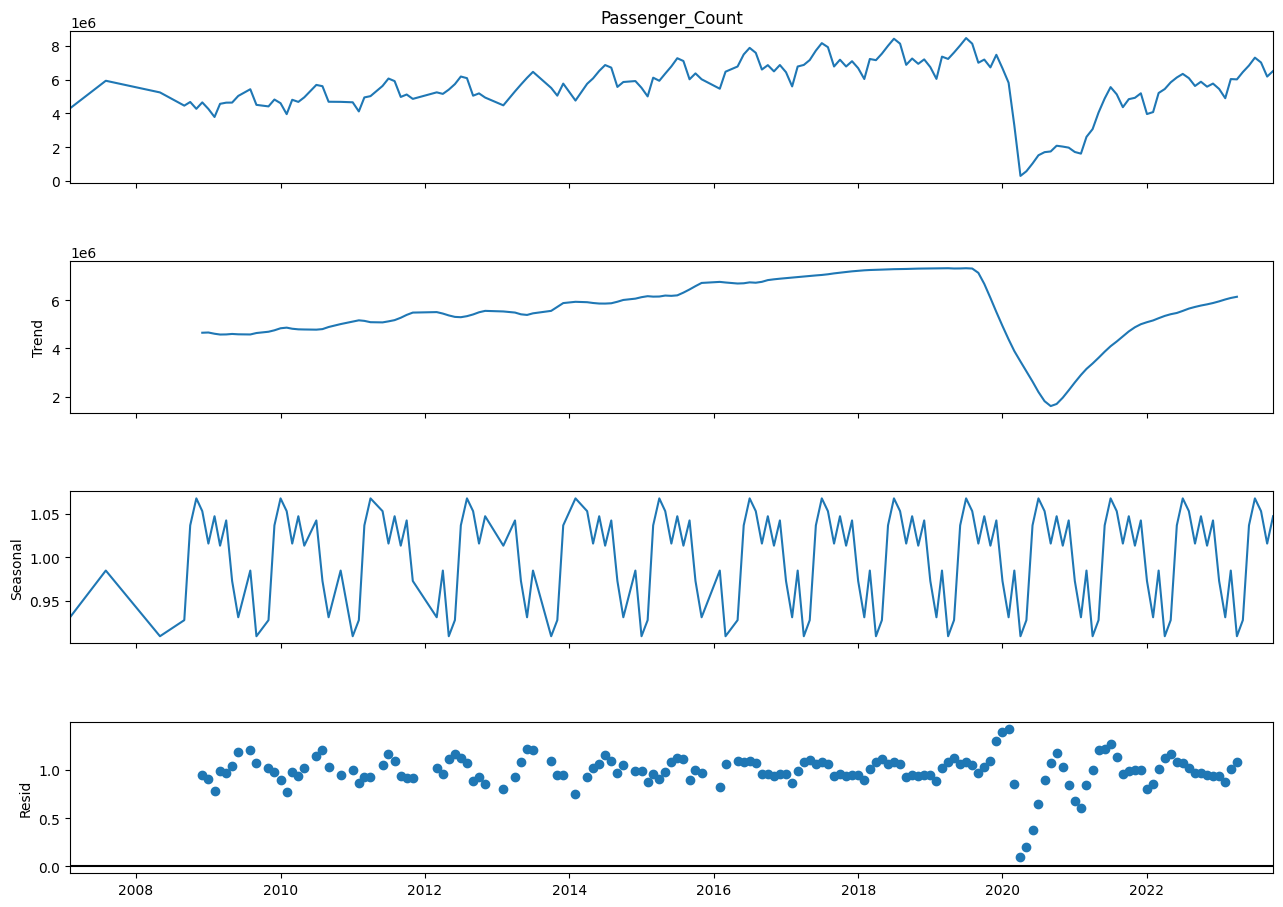

In [ ]:
# Seasonal Decompose
decomp = seasonal_decompose(monthly_total, model="multiplicative", period=12)
fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.show()

The seasonal decomposition of LAX passenger traffic shows a clear long-term upward trend from the late 2000s through 2019. It reflects steady growth in air travel demand, followed by a dramatic and abrupt decline around 2020 due to the COVID-19 pandemic. After this sharp drop, passenger volumes begin a gradual recovery, though they have not fully returned to the pre-pandemic peak by the end of the period shown. The seasonal component is strong and consistent, indicating predictable monthly fluctuations in passenger traffic (likely tied to travel seasons such as summer peaks and winter dips). Meanwhile, the residuals are relatively stable over time except for significant volatility during the pandemic period. This highlights the unusually large disruption that cannot be explained by normal trend or seasonality.

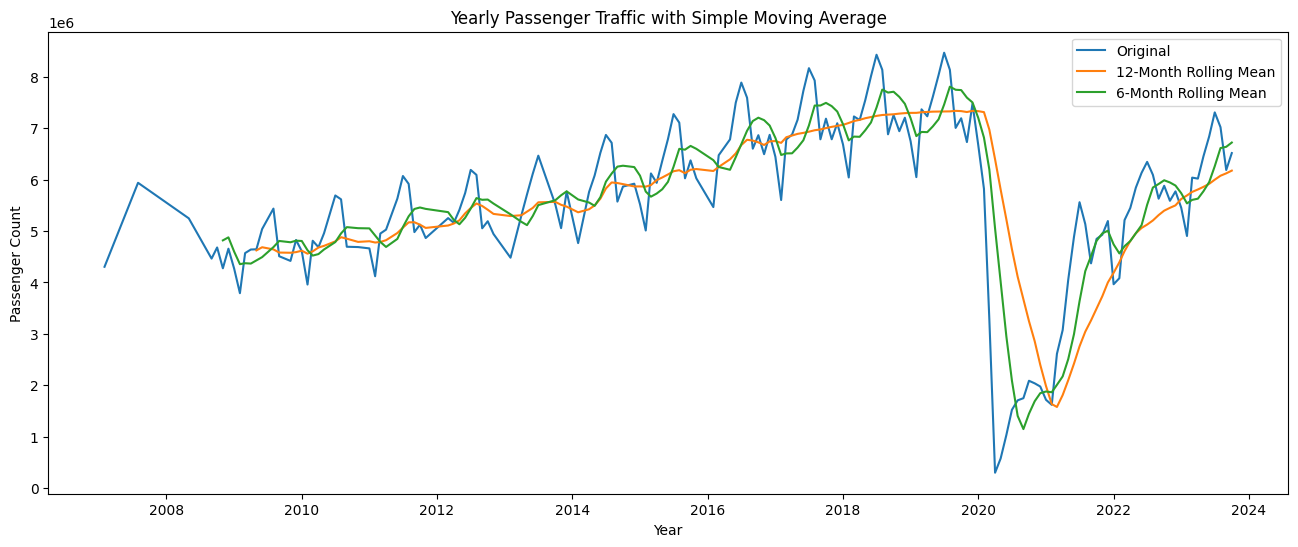

In [ ]:
# Simple Rolling Average
rolling_12 = monthly_total.rolling(window=12).mean()
rolling_6 = monthly_total.rolling(window=6).mean()

plt.figure(figsize=(16, 6))
plt.plot(monthly_total.index, monthly_total, label="Original")
plt.plot(rolling_12.index, rolling_12, label="12-Month Rolling Mean")
plt.plot(rolling_6.index, rolling_6, label="6-Month Rolling Mean")
plt.title("Yearly Passenger Traffic with Simple Moving Average")
plt.xlabel("Year")
plt.ylabel("Passenger Count")
plt.legend()
plt.show()

This chart of LAX passenger traffic with moving averages highlights a steady upward trend from the late 2000s through 2019, with regular seasonal fluctuations visible in the original data. The 6-month and 12-month rolling means smooth out these short-term variations and confirm consistent long-term growth leading up to the pandemic.

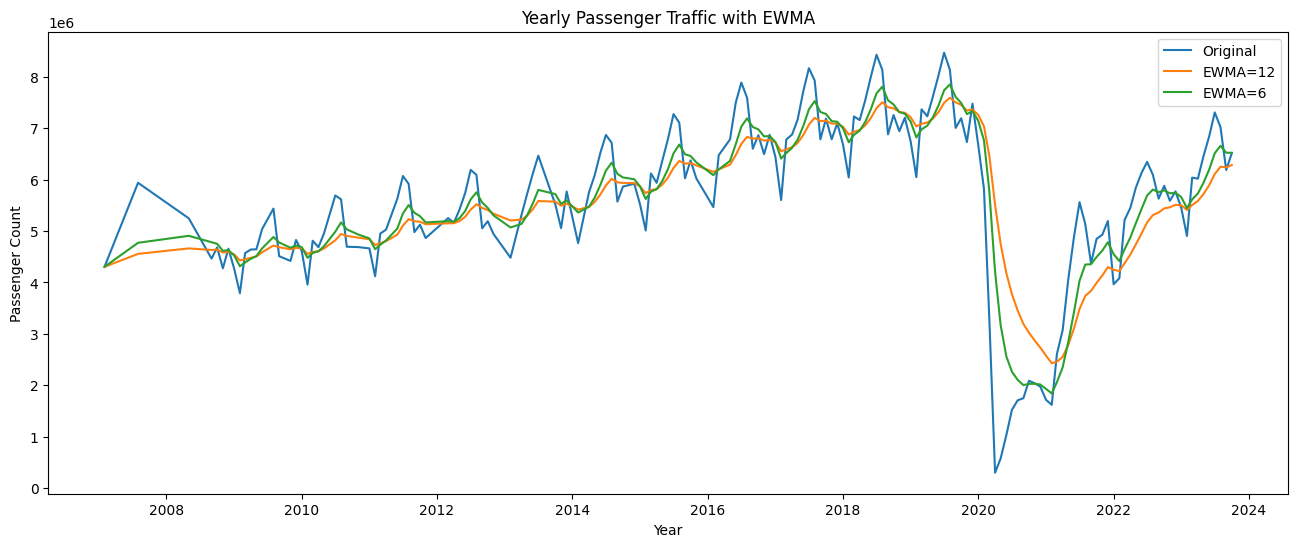

In [ ]:
# EWMA (Exponentially Weighted Moving Average)
ewma_12 = monthly_total.ewm(span=12, adjust=False).mean()
ewma_6 = monthly_total.ewm(span=6, adjust=False).mean()

plt.figure(figsize=(16, 6))
plt.plot(monthly_total.index, monthly_total, label="Original")
plt.plot(ewma_12.index, ewma_12, label="EWMA=12")
plt.plot(ewma_6.index, ewma_6, label="EWMA=6")
plt.title("Yearly Passenger Traffic with EWMA")
plt.xlabel("Year")
plt.ylabel("Passenger Count")
plt.legend()
plt.show()

This EWMA chart of LAX passenger traffic shows a steady upward trend from 2007 to 2019, with the smoothed lines (especially EWMA=12) highlighting consistent long-term growth despite seasonal fluctuations. In 2020, there is a sharp and sudden decline in passenger volume, with the EWMA=6 responding more quickly to the drop than the smoother EWMA=12. From 2021 onward, both indicators show a gradual recovery, though levels remain slightly below the pre-pandemic peak by the end of the period.

## Checking for Stationarity Using ACF and Plot Visualiazation

After running some time series analysis, we can see that the data shows a seasonal pattern. As a result, we’ll check whether the series is stationary by looking at ACF plots and visualizations. We use ACF because it helps us see how values are related over different time lags, which makes patterns like seasonality easier to spot. Checking for stationarity is important since many time series models assume the data stays consistent over time.

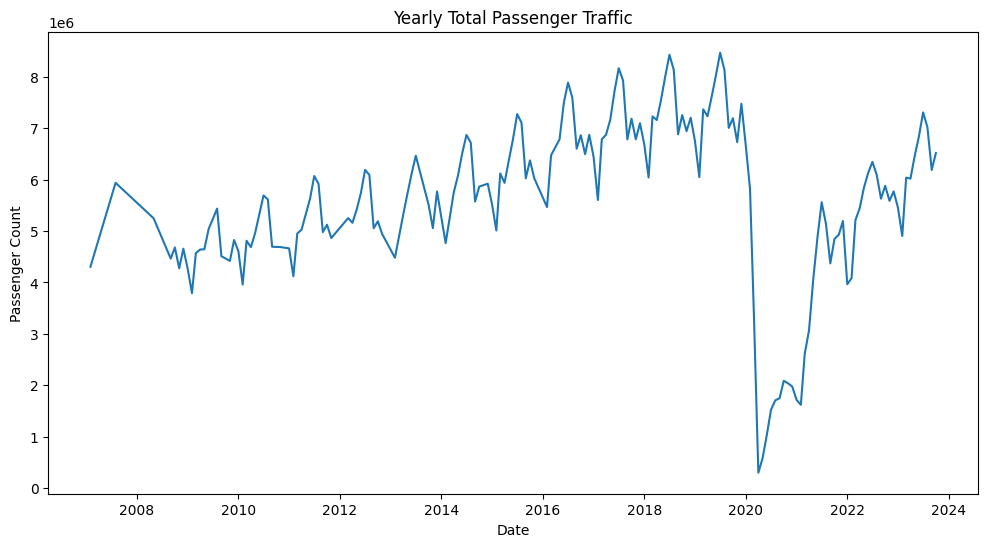

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_total.index,monthly_total)
plt.title('Yearly Total Passenger Traffic')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.show()

This basic time-series plot showcase signs of seasonality, with consistent growth and decline on seasonality basics. The only exception would be the dramatic drop in 2020, but that is due to COVID-19. Similarly, repeating patterns of seasonality and growth occur after 2021, but not to the same levels prior the 2020 crash

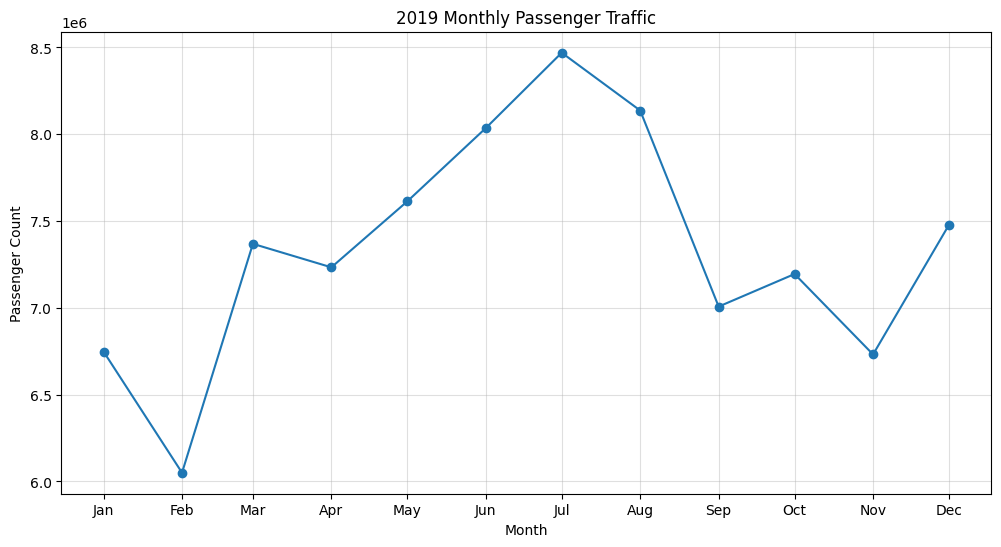

In [ ]:
# Checking a specific year for seasonlity (2019 & 2017)
year19_data = monthly_total[monthly_total.index.year == 2019]

plt.figure(figsize=(12,6))
plt.plot(year19_data, marker='o')
plt.title('2019 Monthly Passenger Traffic')
plt.xlabel('Month')
plt.ylabel('Passenger Count')

# Format x-axis to show month names
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.grid(True, alpha=0.4)
plt.show()

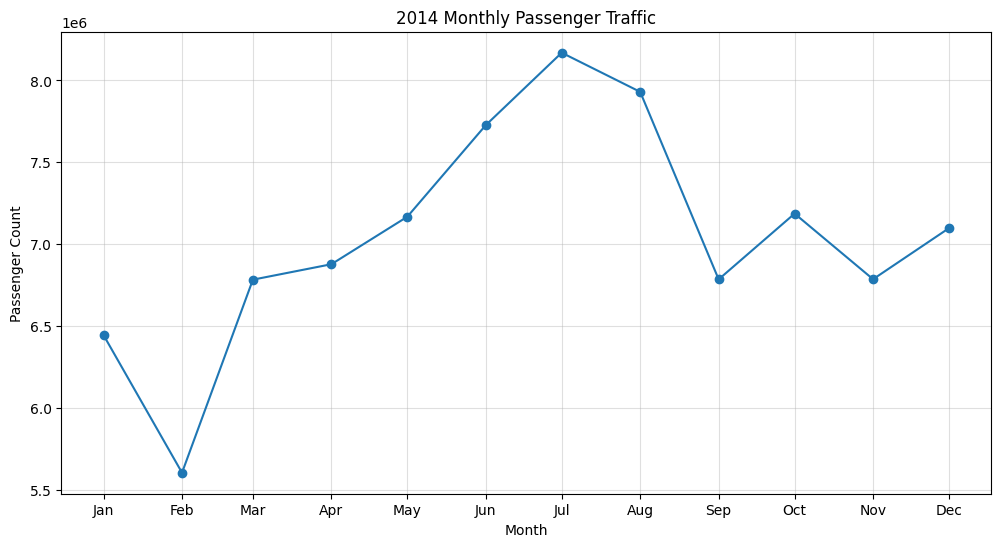

In [ ]:
# Checking a specific year for seasonlity (2019 & 2017)
year17_data = monthly_total[monthly_total.index.year == 2017]

plt.figure(figsize=(12,6))
plt.plot(year17_data, marker='o')
plt.title('2014 Monthly Passenger Traffic')
plt.xlabel('Month')
plt.ylabel('Passenger Count')

# Format x-axis to show month names
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.grid(True, alpha=0.4)
plt.show()

Both monthly graphs points towards non-stationary, as it exhibits a strong seasonal pattern rather than a constant mean over time. Passenger traffic drops consistently during the early winter months (around January–February), followed by a steady increase through the spring and into the summer. The peak occurs in mid-year (around July–August), indicating heightened travel demand during the summer season. After this peak, there is a gradual decline into the autumn months, with a slight recovery toward the end of the year. Overall, the repeating pattern of winter lows and summer highs highlights seasonality in passenger volumes.

--- Plotting ACF ---


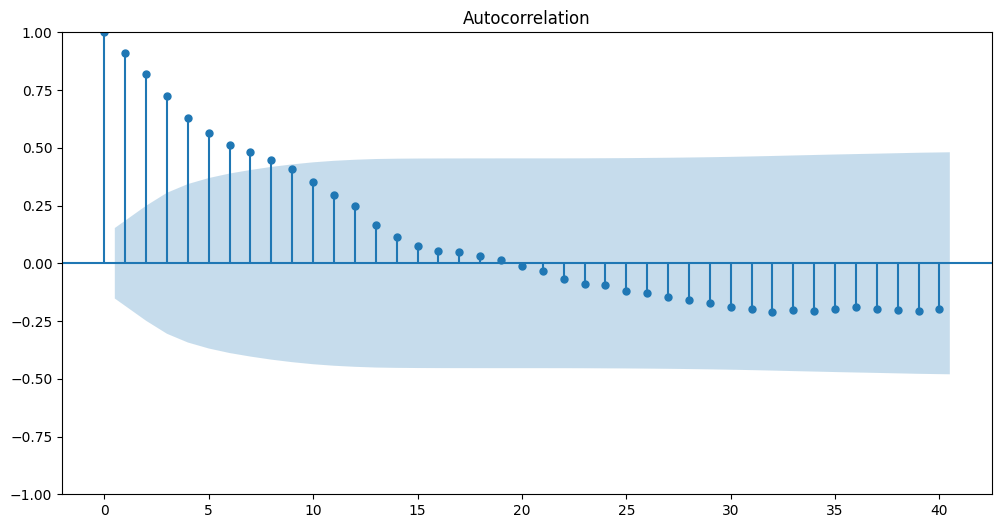

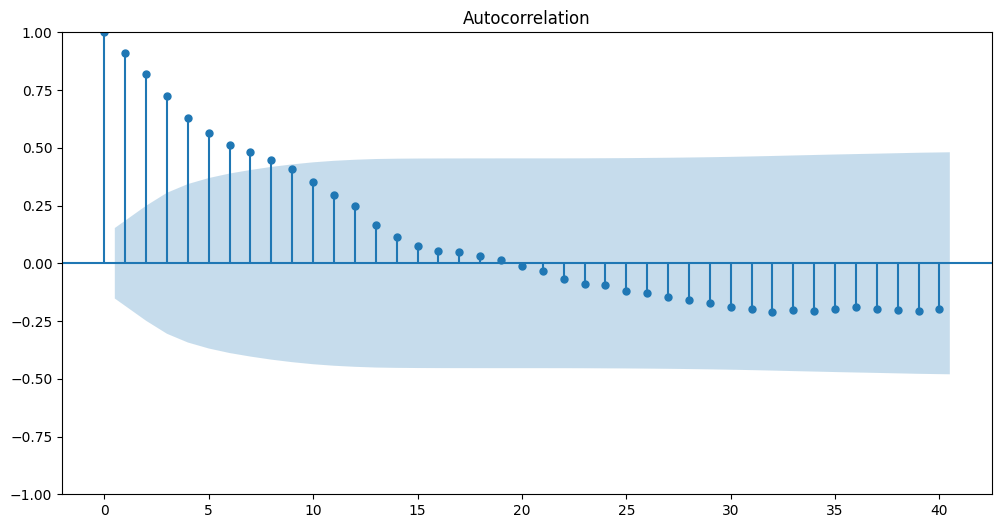

In [ ]:
print("--- Plotting ACF ---")
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(monthly_total, lags=40, ax=ax)

The ACF plot shows strong positive autocorrelation at lower lags, indicating that LAX passenger traffic is highly dependent on its recent past values. The slow decay of autocorrelation suggests a persistent trend component rather than a purely random process. As lags increase, the correlation becomes weak and slightly negative, implying diminishing influence over time and potential seasonal effects.

In [ ]:
print("--- Running Augmented Dickey-Fuller (ADF) Test ---")

# The adfuller() function returns several values, but we care most about [1], the p-value
adf_result = adfuller(monthly_total)

print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'\t{key}: {value}')

print("\n--- CONCLUSION ---")
print(f"The p-value is {adf_result[1]:.4f}.")
if adf_result[1] > 0.05:
    print("p-value > 0.05. We FAIL to reject the null hypothesis (H0).")
    print("This means the data IS NON-STATIONARY.")
else:
    print("p-value <= 0.05. We REJECT the null hypothesis (H0).")
    print("This means the data IS STATIONARY.")

--- Running Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -2.84835921463894
p-value: 0.05169111435287208
Critical Values:
	1%: -3.471118535474365
	5%: -2.8794405060097024
	10%: -2.576313761526591

--- CONCLUSION ---
The p-value is 0.0517.
p-value > 0.05. We FAIL to reject the null hypothesis (H0).
This means the data IS NON-STATIONARY.


### Testing For Stationarity Results
Our data failed the ACF test, both in terms of the test results and what we see in the plots. This suggests the series is non-stationary. As a result, we need to apply future transformations such as differencing to make the data stationary before moving forward with modeling. However, some models can run with non-stationarity data as transforming & differencing is built within their modeling process. Since we are leaning towards a SARIMA model based on previous data, we will keep the data non-stationarity for now.

### Fixing Stationarity

Since we observe a clear seasonal trend in our seasonal decomposition and visualizations, we can leverage a SARIMA model to address non-stationarity by incorporating both seasonal and non-seasonal differencing components. This allows us to effectively model repeating patterns over time while stabilizing the mean of the series. By tuning the seasonal parameters, the model can capture periodic fluctuations in traffic volume, leading to more accurate and reliable forecasts.

# SARIMA MODEL

It seems that a SARIMA model is best suited for the LAX dataset because it contains both a long-term trend and a strong seasonal component. LAX passenger traffic shows repeating monthly patterns, with higher travel during summer and holidays, along with overall growth and a major shock in 2020. Unlike ARIMA, SARIMA can capture both the trend and these seasonal patterns, making it more appropriate and accurate for this type of data.

In [ ]:
!pip install pmdarima

In [ ]:
import pmdarima as pm
from pmdarima.arima import auto_arima

In [ ]:
# Finding the best SARIMA model with the optimal non-seasonal order (p,dq) and seasonal order(P,D,Q,12)
model = auto_arima(monthly_total, seasonal=True, m=12)
print("Best model found:", model.order, model.seasonal_order)


Best model found: (1, 0, 1) (2, 0, 0, 12)


In [ ]:
print(model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  165
Model:             SARIMAX(1, 0, 1)x(2, 0, [], 12)   Log Likelihood               -2434.492
Date:                             Mon, 04 May 2026   AIC                           4880.983
Time:                                     06:38:37   BIC                           4899.619
Sample:                                          0   HQIC                          4888.548
                                             - 165                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   5.175e+05   2.21e+05      2.343      0.019    8.46e+04     9.5e+05
ar.L1          0.8653      

These results are good enough to continue modeling, with key coefficients such as AR, MA, and seasonal terms being statistically significant (p < 0.05). The Ljung-Box test also suggests that residuals are not autocorrelated, indicating a good model fit.

In [ ]:
# Saving the best orders
best_order = model.order
best_seasonal = model.seasonal_order

In [ ]:
# Running & Fitting the SARMIA model
model = SARIMAX(monthly_total, order=best_order, seasonal_order=best_seasonal)

results = model.fit(disp=False)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                     Passenger_Count   No. Observations:                  165
Model:             SARIMAX(1, 0, 1)x(2, 0, [], 12)   Log Likelihood               -2439.598
Date:                             Mon, 04 May 2026   AIC                           4889.195
Time:                                     06:38:39   BIC                           4904.725
Sample:                                          0   HQIC                          4895.499
                                             - 165                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9813      0.018     54.249      0.000       0.946       1.017
ma.L1          0.1739      

These results are solid and appropriate to continue with, as all key coefficients (AR, MA, and both seasonal terms) are statistically significant (p < 0.05), indicating the model is capturing both trend and seasonal patterns well. The Ljung-Box test (p = 0.95) suggests no autocorrelation in the residuals, which supports a good model fit.

# Model Predicting & Forecasting

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gathering Prediction
predictions = results.fittedvalues.dropna()

# Gathering actual values
aligned_actual = monthly_total.loc[predictions.index]

In [ ]:
# Testing model accuracy
mae = mean_absolute_error(aligned_actual, predictions)
rmse = np.sqrt(mean_squared_error(aligned_actual, predictions))
mape = np.mean(np.abs((aligned_actual - predictions) / aligned_actual)) * 100
r2 = r2_score(aligned_actual, predictions)

In [ ]:
print("\n" + "="*70)
print("MODEL PERFORMANCE METRICS")
print("="*70)
print(f"MAE (Mean Absolute Error):        {mae:,.2f}")
print(f"RMSE (Root Mean Squared Error):   {rmse:,.2f}")
print(f"MAPE (Mean Absolute % Error):     {mape:.2f}%")
print(f"R² (Coefficient of Determination): {r2:.4f}")
print(f"Number of observations:            {len(aligned_actual)}")


MODEL PERFORMANCE METRICS (In-Sample)
MAE (Mean Absolute Error):        503,715.01
RMSE (Root Mean Squared Error):   712,690.94
MAPE (Mean Absolute % Error):     15.06%
R² (Coefficient of Determination): 0.7970
Number of observations:            165


The performance metrics suggest the model is good and somewhat robust. The R^2 of 0.79 explain about 80% of variation in the passenger traffic and the MAPE of 15% indicate reasonable forecasting accuracy. THe high MAE and RMSE around 500-700k accounts for around 10-15% of average values and can be accounted for due to the high scale of the data itself. The model performacne is solid and runs well.  

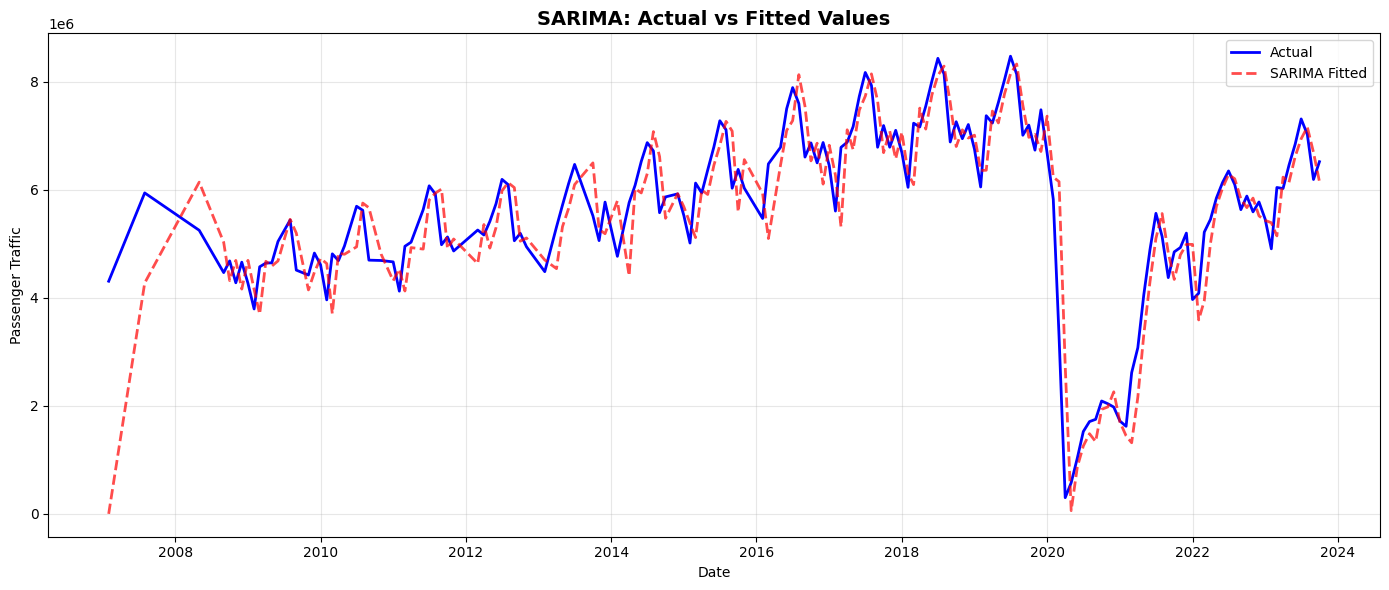

In [ ]:
# Actual vs Prediction Plot
plt.figure(figsize=(14, 6))
plt.plot(aligned_actual.index, aligned_actual.values,
         label='Actual', linewidth=2, color='blue')
plt.plot(predictions.index, predictions.values,
         label='SARIMA Fitted', linewidth=2, linestyle='--',
         color='red', alpha=0.7)
plt.title(f'SARIMA: Actual vs Fitted Values',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Passenger Traffic')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The SARIMA model fits the LAX passenger data quite well overall, as the fitted values closely track the actual data across most of the time period. It successfully captures both the upward trend and the recurring seasonal patterns, though there are some small deviations at peaks and troughs. The largest errors occur around the sharp drop in 2020, which is expected since sudden shocks are difficult for time series models to predict accurately.

In [ ]:
# Generating forecasting prediciation
forecast = results.forecast(steps=12)
forecast_ci = results.get_forecast(steps=12).conf_int()

future_dates = pd.date_range(start=monthly_total.index[-1] + pd.DateOffset(months=1),
                             periods=12, freq='MS')

print("\nFuture Predictions:")
for date, value, lower, upper in zip(future_dates, forecast,
                                      forecast_ci.iloc[:, 0],
                                      forecast_ci.iloc[:, 1]):
    print(f"{date.strftime('%Y-%m')}: {value:,.0f} (CI: {lower:,.0f} - {upper:,.0f})")


Future Predictions:
2023-11: 6,447,127 (CI: 5,191,688 - 7,702,565)
2023-12: 6,443,193 (CI: 4,525,033 - 8,361,354)
2024-01: 6,105,464 (CI: 3,717,019 - 8,493,909)
2024-02: 5,923,775 (CI: 3,157,009 - 8,690,540)
2024-03: 6,261,043 (CI: 3,173,473 - 9,348,613)
2024-04: 6,214,827 (CI: 2,847,092 - 9,582,561)
2024-05: 6,292,128 (CI: 2,675,056 - 9,909,199)
2024-06: 6,344,601 (CI: 2,502,689 - 10,186,512)
2024-07: 6,403,902 (CI: 2,357,267 - 10,450,537)
2024-08: 6,231,590 (CI: 1,997,158 - 10,466,022)
2024-09: 5,910,434 (CI: 1,502,716 - 10,318,153)
2024-10: 5,950,052 (CI: 1,381,672 - 10,518,432)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


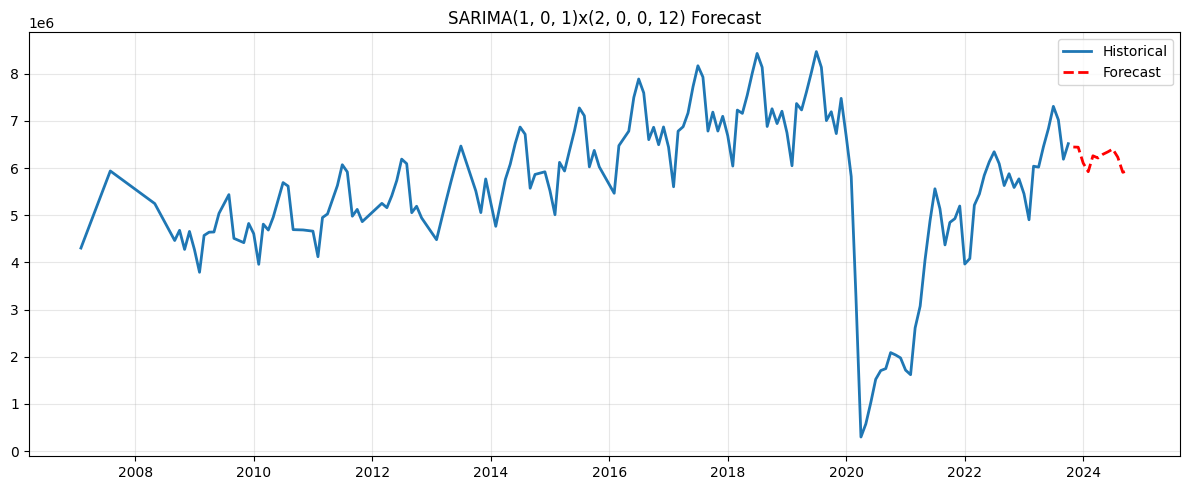

In [ ]:
# Forecast Prediction Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_total.index, monthly_total, label='Historical', linewidth=2)
plt.plot(future_dates, forecast, label='Forecast', linewidth=2, linestyle='--', color='red')

plt.legend()
plt.grid(alpha=0.3)
plt.title(f'SARIMA{best_order}x{best_seasonal} Forecast')
plt.tight_layout()

## Conclusion

The forecast suggest that LAX passegner traffic is expected to reamin relatively stable in the near term, hovering around 6-6.5 million passenger with slight seasonal fluctuations. The predication is also conservative within it's esimates showing decreased volume late into 2024 and early 2025. This reflect the historical seasonal patterns, with regular ups and downs rather than sharp growth or decline. This predicition follow similar historical trends of decreasing pasenger volume during seasonal shifts. Overall, it predicts a steady recovery but no immediate return to the pre-2020 peak levels.